# **Fake News Detection using Natural Language Processing**

Midterm Presentation  
**Baseline - DONE** | **Advanced Models - DONE** | SHAP - done, but idk if we should sow it now or in the final one

The dataset contains ~12,800 short political statements from **POLITIFACT.com**, labeled with one of **6 truthfulness ratings**:

| Label | Meaning |
|---|---|
| `pants-fire` | Complete nonsense ("Liar Liar Pants on Fire") |
| `false` | False |
| `barely-true` | Barely true |
| `half-true` | Half-true |
| `mostly-true` | Mostly true |
| `true` | True |


In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import re
import copy
warnings.filterwarnings('ignore')
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, roc_auc_score, ConfusionMatrixDisplay
from sklearn.calibration import CalibratedClassifierCV
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import shap
import mlflow
import mlflow.sklearn
from nltk.corpus import stopwords
import nltk
from sklearn.impute import SimpleImputer

nltk.download('stopwords', quiet=True)
STOP_WORDS = set(stopwords.words('english'))

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

LABEL_ORDER  = ['pants-fire', 'false', 'barely-true', 'half-true', 'mostly-true', 'true']
LABEL_COLORS = ['#d32f2f', '#f44336', '#ff9800', '#ffc107', '#8bc34a', '#4caf50']

MAP_3CLASS = {
    'pants-fire': 'fake',
    'false':      'fake',
    'barely-true':'mixed',
    'half-true':  'mixed',
    'mostly-true':'real',
    'true':       'real',
}
MAP_BINARY = {
    'pants-fire': 0,
    'false':      0,
    'barely-true':0,
    'half-true':  1,
    'mostly-true':1,
    'true':       1,
}

COUNT_COLS = ['barely_true_counts', 'false_counts', 'half_true_counts', 'mostly_true_counts', 'pants_fire_counts']

## **Data Loading & Validation**

In [56]:
LIAR_COLUMNS = [
    'id', 'label', 'statement', 'subjects', 'speaker', 'job_title',
    'state', 'party',
    'barely_true_counts', 'false_counts', 'half_true_counts',
    'mostly_true_counts', 'pants_fire_counts',
    'context',
]

COUNT_COLS = [
    'barely_true_counts', 'false_counts', 'half_true_counts',
    'mostly_true_counts', 'pants_fire_counts'
]

train = pd.read_csv('train.tsv', sep='\t', names=LIAR_COLUMNS, header=0)
test = pd.read_csv('test.tsv', sep='\t', names=LIAR_COLUMNS, header=0)
valid = pd.read_csv('valid.tsv', sep='\t', names=LIAR_COLUMNS, header=0)

print('Train shape:', train.shape)
print('Test shape:', test.shape)
print('Valid shape:', valid.shape)
print('All together:', train.shape[0] + test.shape[0] + valid.shape[0])

train.head(5)

Train shape: (10239, 14)
Test shape: (1266, 14)
Valid shape: (1283, 14)
All together: 12788


,id,label,statement,subjects,speaker,job_title,state,party,barely_true_counts,false_counts,half_true_counts,mostly_true_counts,pants_fire_counts,context
0,10540.json,half-true,When did the decline of coal start? It started...,"energy,history,job-accomplishments",scott-surovell,State delegate,Virginia,democrat,0.0,0.0,1.0,1.0,0.0,a floor speech.
1,324.json,mostly-true,"Hillary Clinton agrees with John McCain ""by vo...",foreign-policy,barack-obama,President,Illinois,democrat,70.0,71.0,160.0,163.0,9.0,Denver
2,1123.json,false,Health care reform legislation is likely to ma...,health-care,blog-posting,NaN,NaN,none,7.0,19.0,3.0,5.0,44.0,a news release
3,9028.json,half-true,The economic turnaround started at the end of ...,"economy,jobs",charlie-crist,NaN,Florida,democrat,15.0,9.0,20.0,19.0,2.0,an interview on CNN
4,12465.json,true,The Chicago Bears have had more starting quart...,education,robin-vos,Wisconsin Assembly speaker,Wisconsin,republican,0.0,3.0,2.0,5.0,1.0,a an online opinion-piece


In [57]:
train.drop(columns=['id'], inplace=True)
test.drop(columns=['id'], inplace=True)
valid.drop(columns=['id'], inplace=True)

In [58]:
print('Missing values in train:\n',train.isnull().sum())
print('\nMissing values in test:\n',test.isnull().sum())
print('\nMissing values in valid:\n',valid.isnull().sum())

Missing values in train:
 label                    0
statement                0
subjects                 2
speaker                  2
job_title             2898
state                 2210
party                    2
barely_true_counts       2
false_counts             2
half_true_counts         2
mostly_true_counts       2
pants_fire_counts        2
context                102
dtype: int64

Missing values in test:
 label                   0
statement               0
subjects                0
speaker                 0
job_title             325
state                 262
party                   0
barely_true_counts      0
false_counts            0
half_true_counts        0
mostly_true_counts      0
pants_fire_counts       0
context                17
dtype: int64

Missing values in valid:
 label                   0
statement               0
subjects                0
speaker                 0
job_title             345
state                 279
party                   0
barely_true_counts      

Idk if some of the collumns with missing values will be used so I dont do anything with this yet

In [59]:
print('Duplicate rows in train:', train.duplicated().sum())
print('Duplicate rows in test:', test.duplicated().sum())
print('Duplicate rows in valid:', valid.duplicated().sum())

Duplicate rows in train: 1
Duplicate rows in test: 0
Duplicate rows in valid: 0


In [60]:
train.drop_duplicates(inplace=True)

## **Exploratory Data Analysis**

only on training data. valid is used to choose the best parameters for models(?), test data to test models

#### **Class Balance**

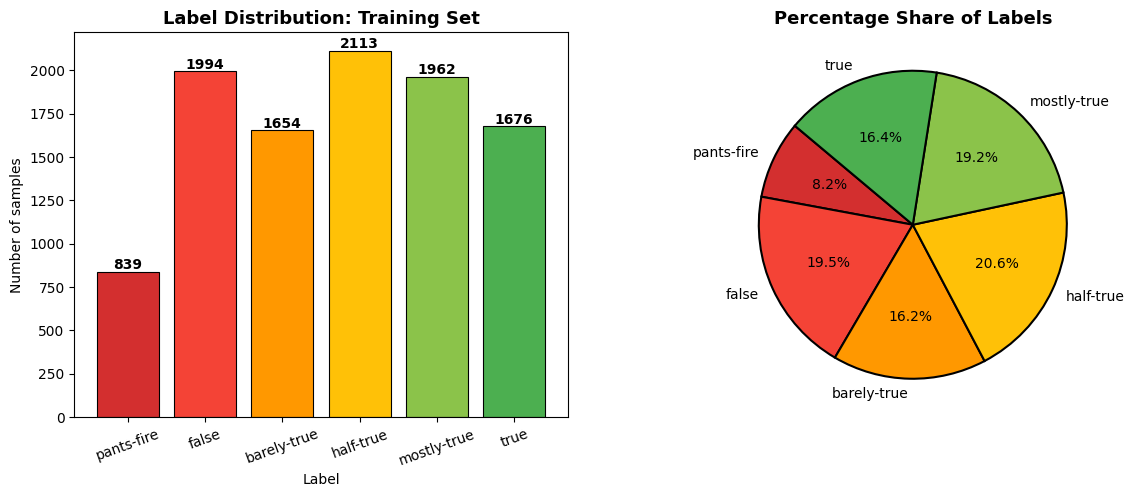

,train,valid,test
label,,,
pants-fire,839,116,92
false,1994,263,249
barely-true,1654,236,212
half-true,2113,248,265
mostly-true,1962,251,241
true,1676,169,207


In [61]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = train['label'].value_counts().reindex(LABEL_ORDER)
bars = axes[0].bar(counts.index, counts.values, color=LABEL_COLORS, edgecolor='black', linewidth=0.8)
axes[0].set_title('Label Distribution: Training Set', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Number of samples')
axes[0].tick_params(axis='x', rotation=20)
for bar, v in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 15, str(v),
                 ha='center', fontsize=10, fontweight='bold')

axes[1].pie(counts.values, labels=counts.index, colors=LABEL_COLORS,
            autopct='%1.1f%%', startangle=140,
            wedgeprops=dict(edgecolor='black', linewidth=1.5))
axes[1].set_title('Percentage Share of Labels', fontsize=13, fontweight='bold')
axes[0].grid(False)
plt.show()

pd.concat([
    train['label'].value_counts().rename('train'),
    valid['label'].value_counts().rename('valid'),
    test['label'].value_counts().rename('test'),
], axis=1).reindex(LABEL_ORDER).fillna(0).astype(int)

The dataset is relatively balanced 

#### **Statement Length Distribution**

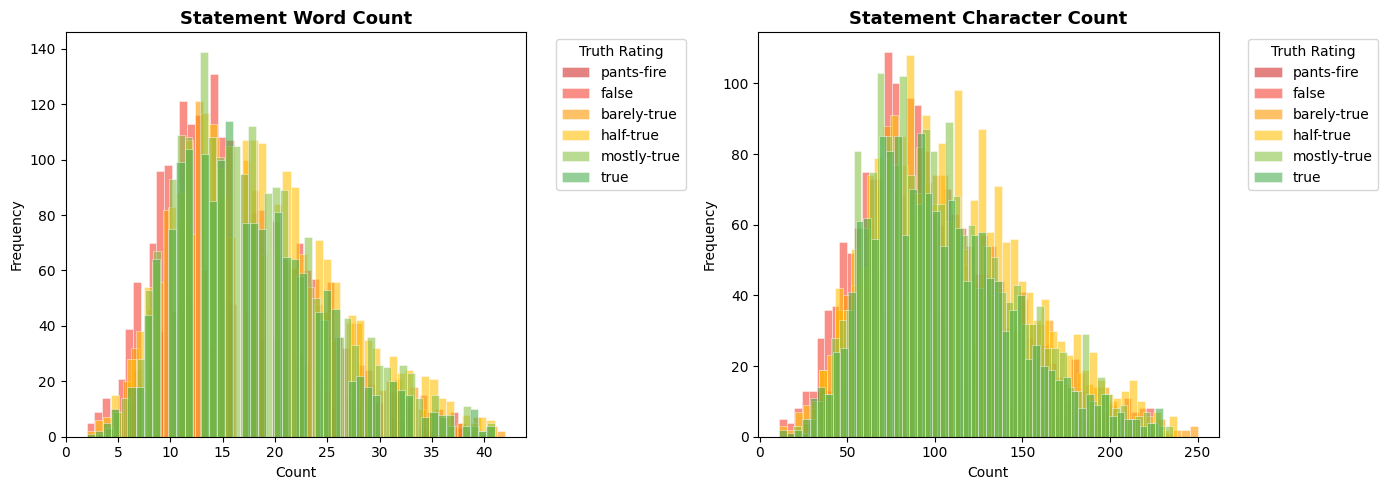

Text Length Statistics by Label (Train Set)


stmt_len        stmt_char_len       
                  mean median          mean median
label                                             
barely-true  18.158404   17.0    108.338573  100.0
false        16.988465   15.5    101.552658   92.0
half-true    18.786559   18.0    111.402272  105.0
mostly-true  18.452599   17.0    109.009684  100.0
pants-fire   17.131108   16.0    102.334923   96.0
true         18.015513   16.0    106.053699   98.0

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

train['stmt_len']        = train['statement'].str.split().str.len()
train['stmt_char_len']   = train['statement'].str.len()


metrics = [
    ('stmt_len', 'Statement Word Count'),
    ('stmt_char_len', 'Statement Character Count')
]

for ax, (col, title) in zip(axes, metrics):
    for label, colour in zip(LABEL_ORDER, LABEL_COLORS):
        subset = train[train['label'] == label][col]
        
        cap = subset.quantile(0.99)
        
        ax.hist(subset[subset <= cap], bins=50, alpha=0.6,
                color=colour, label=label, edgecolor='white', linewidth=0.5)
        
    ax.set_title(title, fontweight='bold', fontsize=13)
    ax.set_xlabel('Count')
    ax.set_ylabel('Frequency')
    ax.legend(title='Truth Rating', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig('eda_statement_length.png', bbox_inches='tight', dpi=300)
plt.show()

print("Text Length Statistics by Label (Train Set)")
display(train.groupby('label')[['stmt_len', 'stmt_char_len']].agg(['mean', 'median']))

#### **Political Party Analisys**

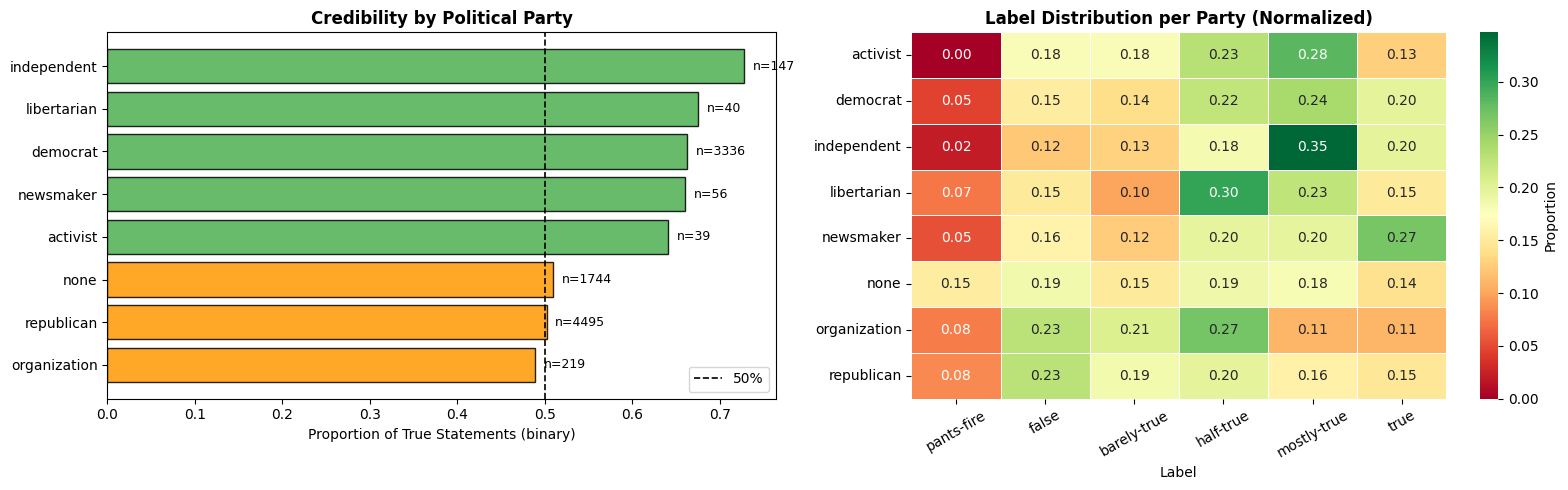

In [63]:
train['binary_label'] = train['label'].map(MAP_BINARY)  # 0=fake, 1=real
train['label_3'] = train['label'].map(MAP_3CLASS)

top_parties = train['party'].value_counts().head(8).index
party_df    = train[train['party'].isin(top_parties)]

party_stats = (
    party_df.groupby('party')['binary_label']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'credibility_rate', 'count': 'n_statements'})
    .sort_values('credibility_rate')
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

colors_party = ['#d32f2f' if r < 0.4 else '#ff9800' if r < 0.55 else '#4caf50'
                for r in party_stats['credibility_rate']]
axes[0].barh(party_stats.index, party_stats['credibility_rate'],
             color=colors_party, alpha=0.85, edgecolor='black')
axes[0].axvline(0.5, color='black', linestyle='--', linewidth=1.2, label='50%')
axes[0].set_xlabel('Proportion of True Statements (binary)')
axes[0].set_title('Credibility by Political Party', fontsize=12, fontweight='bold')
axes[0].legend()

for i, (idx, row) in enumerate(party_stats.iterrows()):
    axes[0].text(row['credibility_rate'] + 0.01, i,
                 f"n={int(row['n_statements'])}", va='center', fontsize=9)

party_label_pivot = (
    party_df.groupby(['party', 'label'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=LABEL_ORDER)
    .div(party_df.groupby('party').size(), axis=0)  # normalization
)

sns.heatmap(party_label_pivot, ax=axes[1], cmap='RdYlGn',
            annot=True, fmt='.2f', linewidths=0.5,
            cbar_kws={'label': 'Proportion'})
axes[1].set_title('Label Distribution per Party (Normalized)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Label')
axes[1].set_ylabel('')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('eda_parties.png', bbox_inches='tight', dpi=300)
plt.show()

#### **Top Comentators**

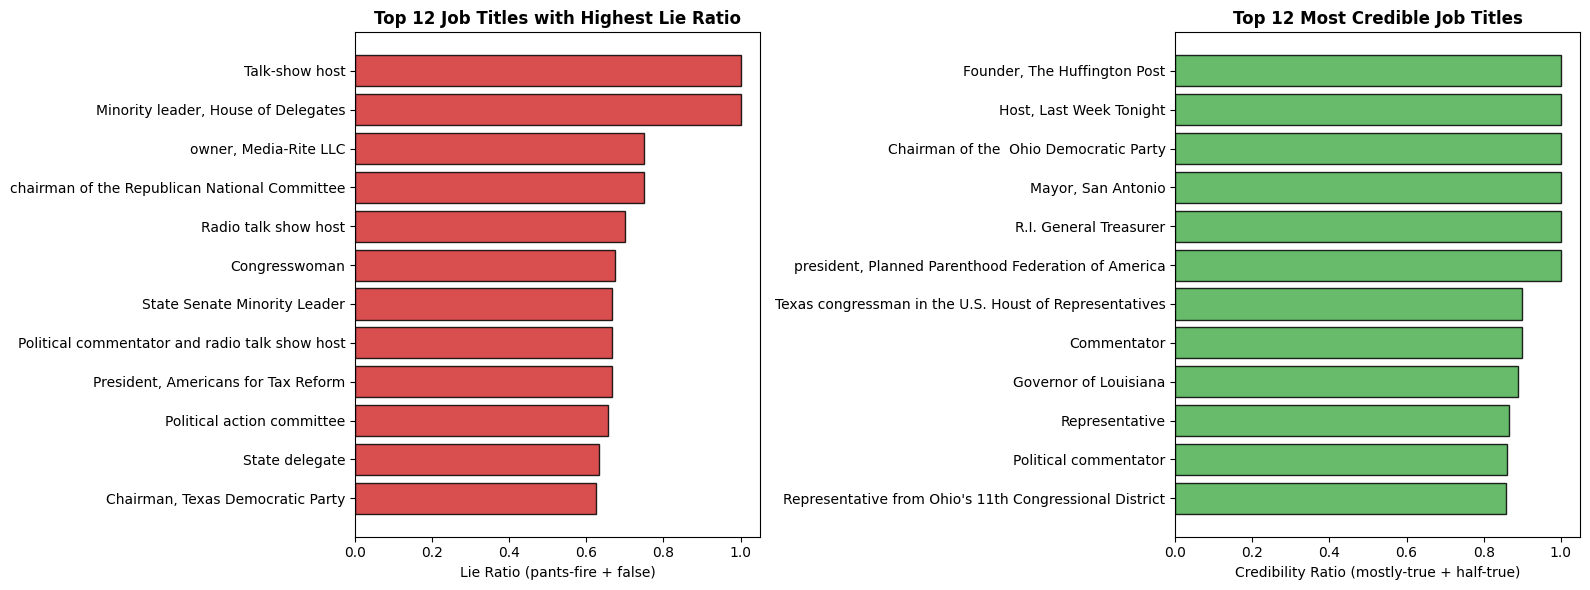

In [64]:
job_stats = (
    train
    .query('job_title != "unknown"') 
    .groupby('job_title')[COUNT_COLS].sum()
    .assign(total=lambda d: d.sum(axis=1))
    .query('total >= 15')
    .assign(
        lie_ratio=lambda d: (d['pants_fire_counts'] + d['false_counts']) / d['total'],
        credibility=lambda d: (d['mostly_true_counts'] + d['half_true_counts']) / d['total']
    )
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_liars = job_stats.sort_values('lie_ratio', ascending=False).head(12)
colors_l = ['#d32f2f' if r > 0.5 else '#ff9800' if r > 0.3 else '#4caf50'
            for r in top_liars['lie_ratio']]

axes[0].barh(top_liars.index[::-1], top_liars['lie_ratio'].values[::-1],
             color=colors_l[::-1], alpha=0.85, edgecolor='black')
axes[0].set_xlabel('Lie Ratio (pants-fire + false)')
axes[0].set_title('Top 12 Job Titles with Highest Lie Ratio',
                  fontsize=12, fontweight='bold')

top_credible = job_stats.sort_values('credibility', ascending=False).head(12)
colors_c = ['#4caf50' if r > 0.6 else '#ff9800' if r > 0.4 else '#d32f2f'
            for r in top_credible['credibility']]

axes[1].barh(top_credible.index[::-1], top_credible['credibility'].values[::-1],
             color=colors_c[::-1], alpha=0.85, edgecolor='black')
axes[1].set_xlabel('Credibility Ratio (mostly-true + half-true)')
axes[1].set_title('Top 12 Most Credible Job Titles',
                  fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_job_titles.png', bbox_inches='tight', dpi=300)
plt.show()

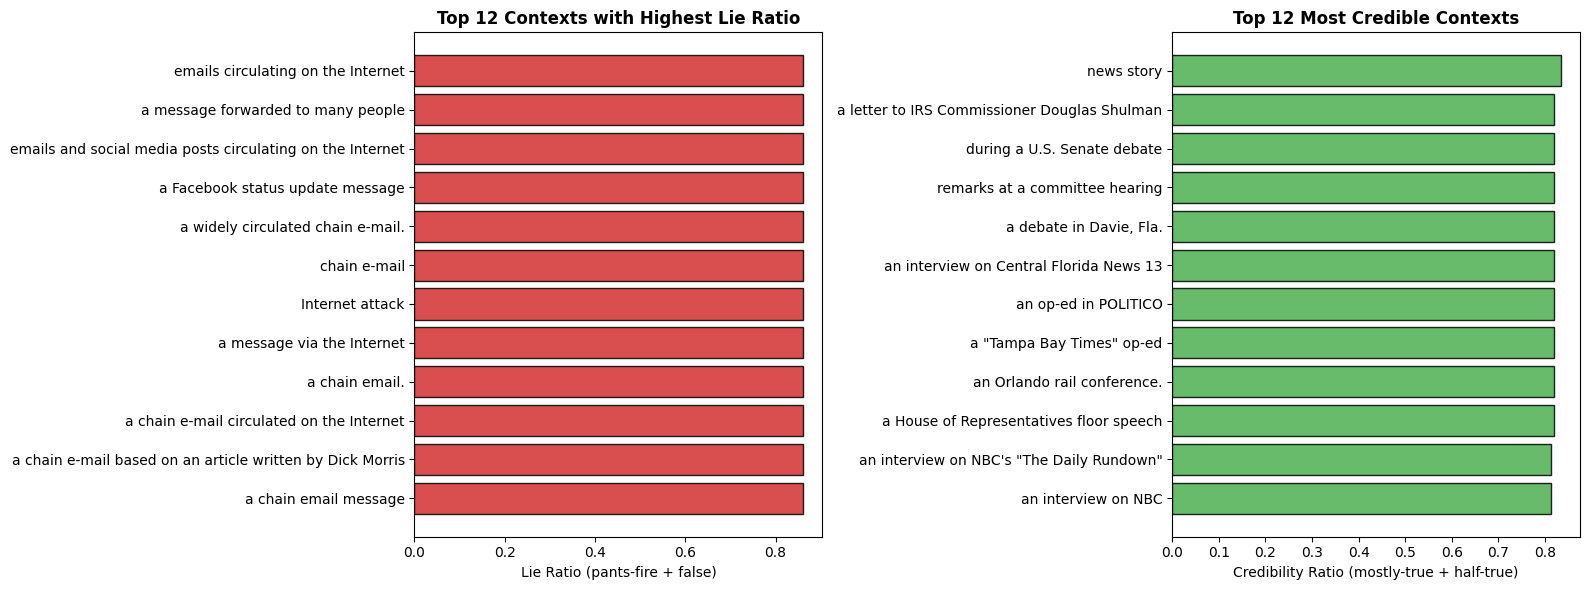

In [65]:
job_stats = (
    train
    .query('job_title != "unknown"') 
    .groupby('context')[COUNT_COLS].sum()
    .assign(total=lambda d: d.sum(axis=1))
    .query('total >= 15')
    .assign(
        lie_ratio=lambda d: (d['pants_fire_counts'] + d['false_counts']) / d['total'],
        credibility=lambda d: (d['mostly_true_counts'] + d['half_true_counts']) / d['total']
    )
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_liars = job_stats.sort_values('lie_ratio', ascending=False).head(12)
colors_l = ['#d32f2f' if r > 0.5 else '#ff9800' if r > 0.3 else '#4caf50'
            for r in top_liars['lie_ratio']]

axes[0].barh(top_liars.index[::-1], top_liars['lie_ratio'].values[::-1],
             color=colors_l[::-1], alpha=0.85, edgecolor='black')
axes[0].set_xlabel('Lie Ratio (pants-fire + false)')
axes[0].set_title('Top 12 Contexts with Highest Lie Ratio',
                  fontsize=12, fontweight='bold')

top_credible = job_stats.sort_values('credibility', ascending=False).head(12)
colors_c = ['#4caf50' if r > 0.6 else '#ff9800' if r > 0.4 else '#d32f2f'
            for r in top_credible['credibility']]

axes[1].barh(top_credible.index[::-1], top_credible['credibility'].values[::-1],
             color=colors_c[::-1], alpha=0.85, edgecolor='black')
axes[1].set_xlabel('Credibility Ratio (mostly-true + half-true)')
axes[1].set_title('Top 12 Most Credible Contexts',
                  fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_contexts.png', bbox_inches='tight', dpi=300)
plt.show()

skip i think

#### **Subject Analisys**

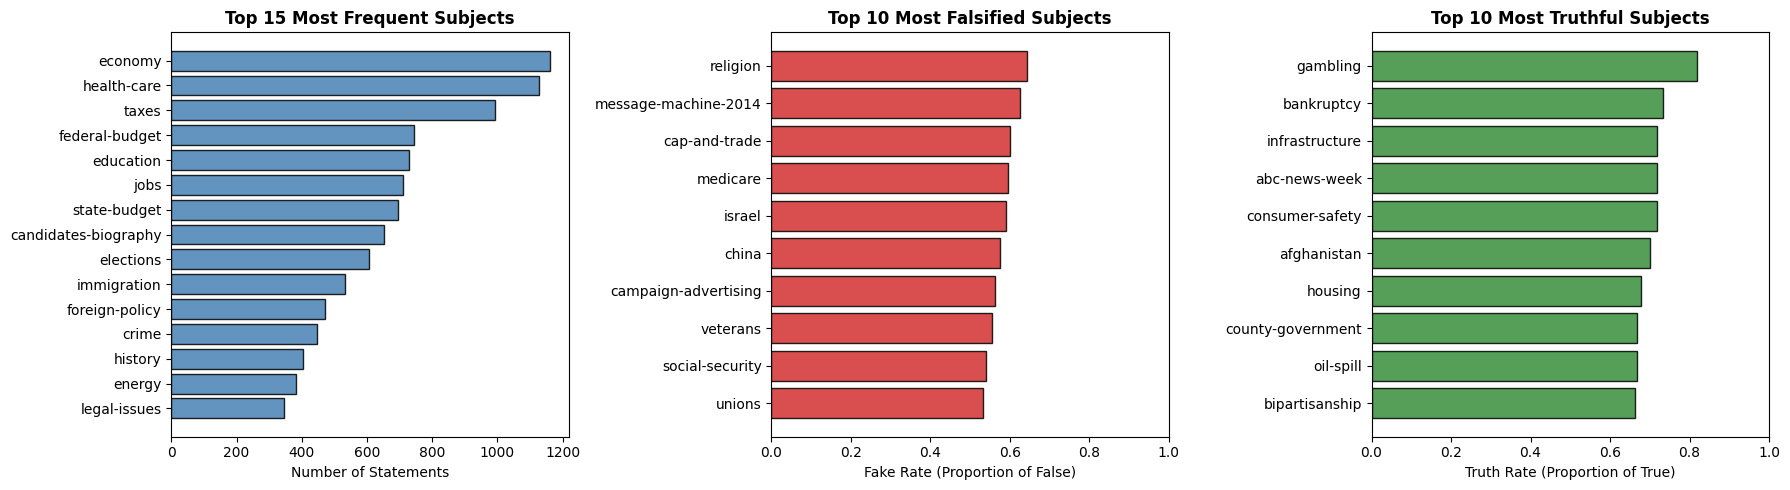

In [66]:
subjects_exploded = (
    train.assign(subject=train['subjects'].str.split(','))
    .explode('subject')
    .assign(subject=lambda d: d['subject'].str.strip())
    .query('subject != "" and subject != "unknown"')
)

top_subjects = subjects_exploded['subject'].value_counts().head(15)

# 3. Calculate truth/fake rates per subject (minimum 30 statements to be statistically valid)
subj_stats = (
    subjects_exploded
    .assign(binary_label=subjects_exploded['label'].map(MAP_BINARY))
    .groupby('subject')['binary_label']
    .agg(['mean', 'count'])
    .query('count >= 30')
)

# Top 10 Fake Subjects 
subj_stats['fake_rate'] = 1.0 - subj_stats['mean']
top_fake = subj_stats.sort_values('fake_rate', ascending=False).head(10)

# Top 10 Real Subjects 
top_real = subj_stats.sort_values('mean', ascending=False).head(10)


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].barh(top_subjects.index[::-1], top_subjects.values[::-1],
             color='steelblue', alpha=0.85, edgecolor='black')
axes[0].set_title('Top 15 Most Frequent Subjects', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Statements')

axes[1].barh(top_fake.index[::-1], top_fake['fake_rate'][::-1],
             color='#d32f2f', alpha=0.85, edgecolor='black')  
axes[1].set_title('Top 10 Most Falsified Subjects', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Fake Rate (Proportion of False)')
axes[1].set_xlim(0, 1)


axes[2].barh(top_real.index[::-1], top_real['mean'][::-1],
             color='#388e3c', alpha=0.85, edgecolor='black') 
axes[2].set_title('Top 10 Most Truthful Subjects', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Truth Rate (Proportion of True)')
axes[2].set_xlim(0, 1)

plt.tight_layout()
plt.savefig('eda_top_subjects.png', bbox_inches='tight', dpi=300)
plt.show()


#### **Lexical Features vs Truthfulness Label**

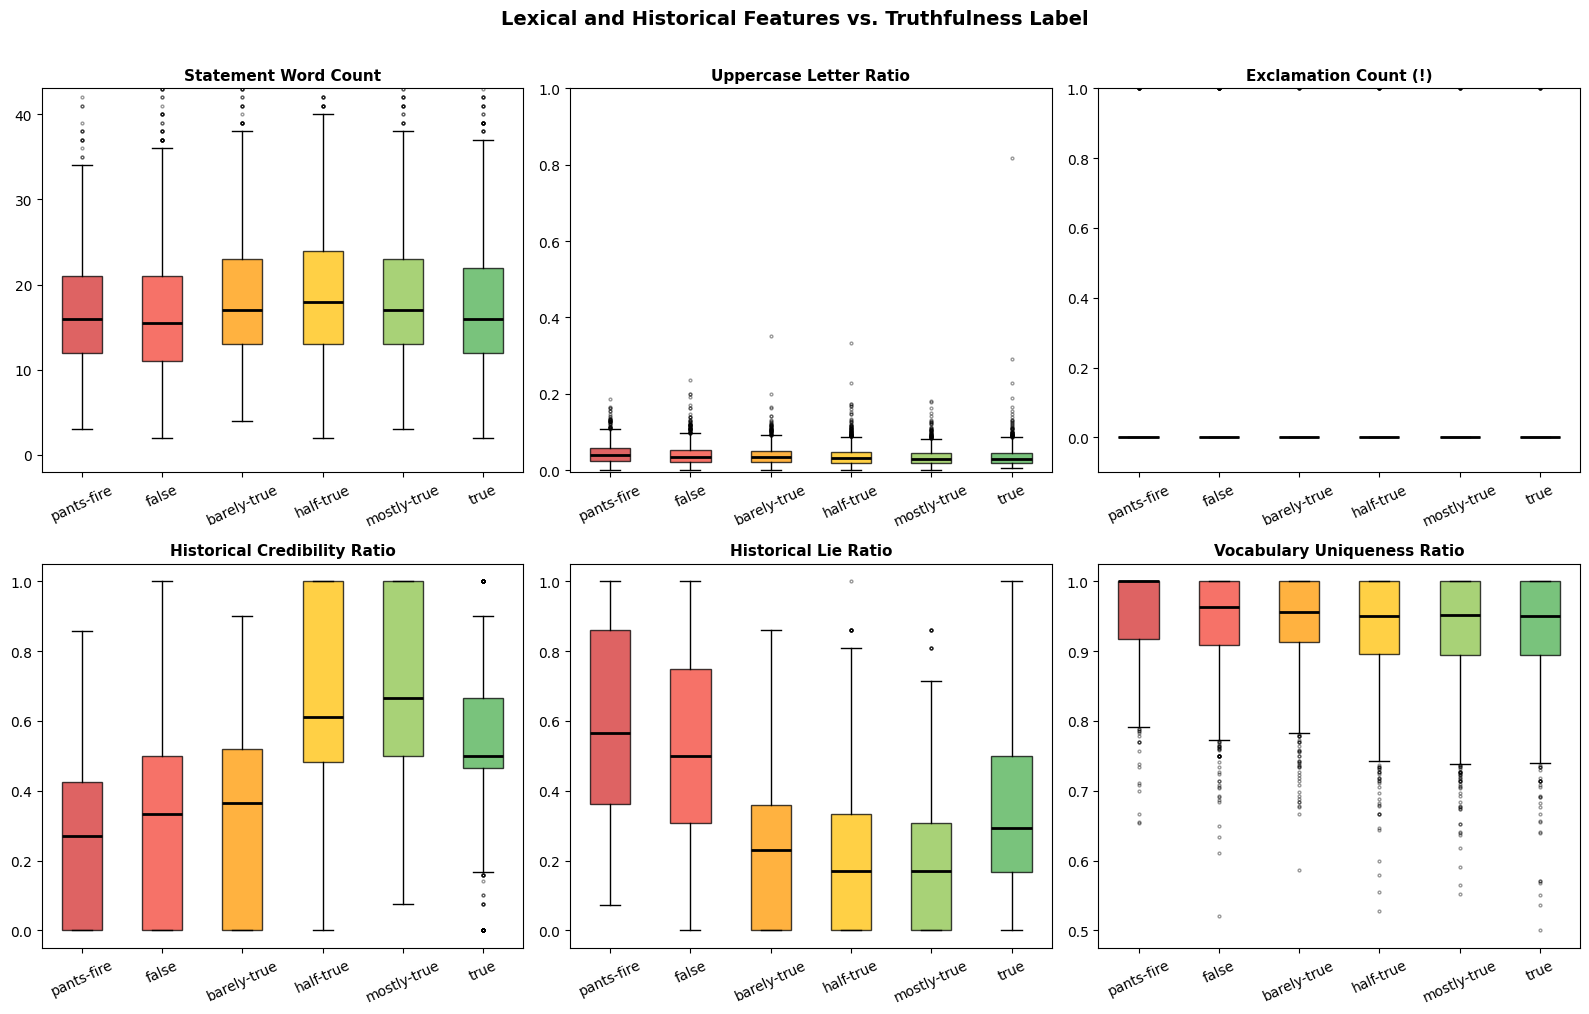

In [67]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

train['exclamation_cnt'] = train['statement'].str.count('!')
train['question_cnt'] = train['statement'].str.count(r'\?')
train['caps_ratio'] = train['statement'].apply(lambda s: sum(1 for c in s if c.isupper()) / max(len(s), 1))
train['unique_word_ratio'] = train['statement'].apply(lambda s: len(set(s.lower().split())) / max(len(s.split()), 1))

train['total_counts'] = train[COUNT_COLS].sum(axis=1)

train['credibility_ratio'] = np.where(
        train['total_counts'] > 0,
        (train['mostly_true_counts'] + train['half_true_counts']) / train['total_counts'],
        0.5
    )

train['lie_ratio'] = np.where(
        train['total_counts'] > 0,
        (train['pants_fire_counts'] + train['false_counts']) / train['total_counts'],
        0.5
    )

lex_features = [
    ('stmt_len', 'Statement Word Count'),
    ('caps_ratio', 'Uppercase Letter Ratio'),
    ('exclamation_cnt', 'Exclamation Count (!)'),
    ('credibility_ratio', 'Historical Credibility Ratio'),
    ('lie_ratio', 'Historical Lie Ratio'),
    ('unique_word_ratio', 'Vocabulary Uniqueness Ratio'),
]

for ax, (col, title) in zip(axes, lex_features):
    data = [train[train['label'] == lbl][col].dropna() for lbl in LABEL_ORDER]
    
    bp = ax.boxplot(data, labels=LABEL_ORDER, patch_artist=True,
                    medianprops=dict(color='black', linewidth=2),
                    flierprops=dict(marker='o', markersize=2, alpha=0.4))

    for patch, color in zip(bp['boxes'], LABEL_COLORS):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
        
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', rotation=25)

    if col in ['stmt_len', 'caps_ratio', 'exclamation_cnt']:
            cap = train[col].quantile(0.99)
            ax.set_ylim(bottom=-0.05 * cap if cap > 0 else -0.1, 
                        top=max(cap * 1.05, 1))

plt.suptitle('Lexical and Historical Features vs. Truthfulness Label', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_lexical_features.png', bbox_inches='tight', dpi=300)
plt.show()


"credibility_ratio" and "lie_ratio" show a very clear trend across labels — these will be strong predictive signals for the model.

#### **Corelation Matrix**

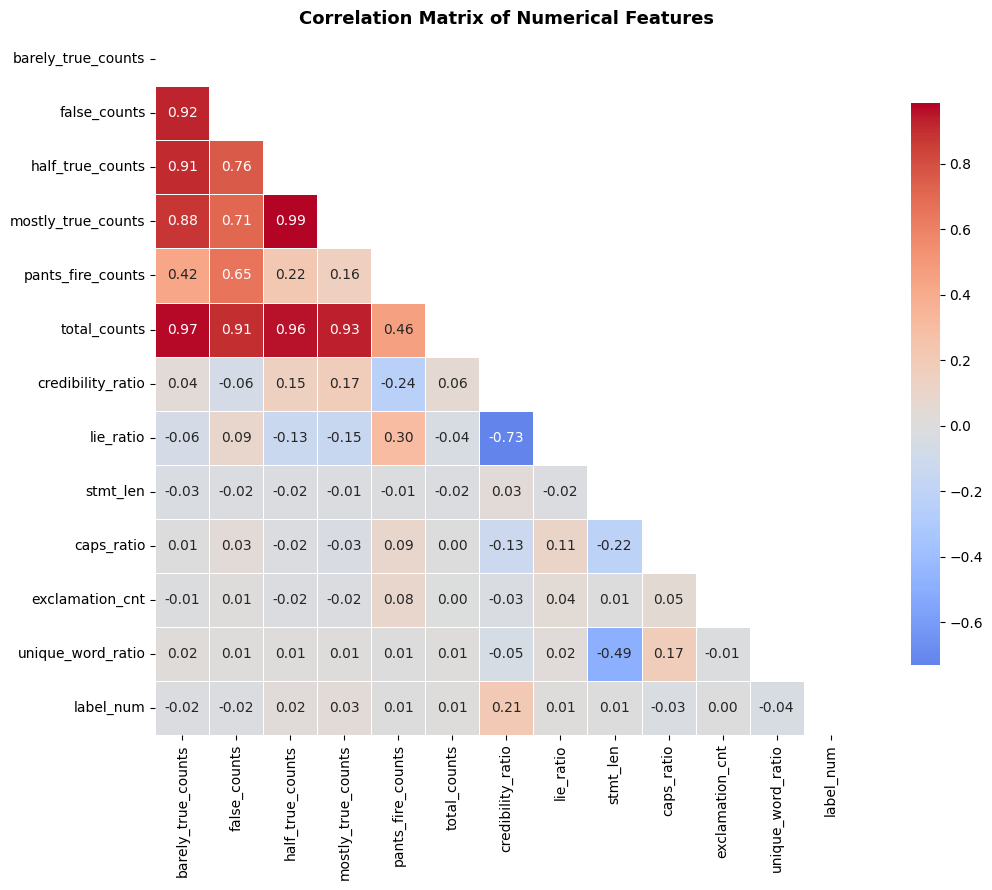

In [68]:
num_cols = COUNT_COLS + ['total_counts', 'credibility_ratio', 'lie_ratio',
                         'stmt_len', 'caps_ratio', 'exclamation_cnt', 'unique_word_ratio']

corr_df = train[num_cols].copy()
corr_df['label_num'] = LabelEncoder().fit_transform(train['label'])

corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(12, 9))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, ax=ax, mask=mask, cmap='coolwarm', center=0,
            annot=True, fmt='.2f', linewidths=0.5,
            square=True, cbar_kws={'shrink': 0.8})

ax.set_title('Correlation Matrix of Numerical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_correlation_matrix.png', bbox_inches='tight', dpi=300)
plt.show()

## **Feature Engineering**

We combine 4 types of features via `ColumnTransformer`:
1. **TF-IDF bigrams** on the concatenated text (statement + speaker + subjects + context)
2. **Speaker history features** (counts + credibility_ratio + lie_ratio)
3. **Lexical features** (length, uppercase ratio, punctuation)
4. **One-hot encoding** of political party and state (top-10 + `other`)


In [72]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)          # remove URLs
    text = re.sub(r'[^a-z\s]', ' ', text)         # keep only letters
    text = re.sub(r'\s+', ' ', text).strip()
    # remove stopwords
    tokens = text.split()
    tokens = [t for t in tokens if t not in STOP_WORDS]
    return ' '.join(tokens)

def build_text_col(df):
    return (
        df['statement'].apply(clean_text) + ' ' +
        df['speaker'].apply(clean_text) + ' ' +
        df['subjects'].apply(clean_text) + ' ' +
        df['context'].apply(clean_text)
    )

def add_derived_features(df):
    df = df.copy()
    df['stmt_len'] = df['statement'].str.split().str.len()
    df['stmt_char_len'] = df['statement'].str.len()
    df['exclamation_cnt'] = df['statement'].str.count('!')
    df['question_cnt'] = df['statement'].str.count(r'\?')
    df['caps_ratio'] = df['statement'].apply(lambda s: sum(1 for c in s if c.isupper()) / max(len(s), 1))
    df['unique_word_ratio'] = df['statement'].apply(lambda s: len(set(s.lower().split())) / max(len(s.split()), 1))
    df['total_counts'] = df[COUNT_COLS].sum(axis=1)
    df['credibility_ratio'] = np.where(
        df['total_counts'] > 0,
        (df['mostly_true_counts'] + df['half_true_counts']) / df['total_counts'],
        0.5
    )
    df['lie_ratio'] = np.where(
        df['total_counts'] > 0,
        (df['pants_fire_counts'] + df['false_counts']) / df['total_counts'],
        0.5
    )
    return df

train = add_derived_features(train)
valid = add_derived_features(valid)
test  = add_derived_features(test)

# Normalise categorical columns to top-N + 'other'
TOP_N = 10
top_parties_list = train['party'].value_counts().head(TOP_N).index.tolist()
top_states_list  = train['state'].value_counts().head(TOP_N).index.tolist()

def normalize_cat(df, col, top_list):
    return df[col].apply(lambda x: x if x in top_list else 'other')

NUMERIC_FEATURES = COUNT_COLS + [
    'total_counts', 'credibility_ratio', 'lie_ratio',
    'stmt_len', 'stmt_char_len', 'caps_ratio',
    'exclamation_cnt', 'question_cnt', 'unique_word_ratio'
]
CATEGORICAL_FEATURES = ['party_norm', 'state_norm']

def build_X(df):
    result = df[NUMERIC_FEATURES].copy().astype(float).fillna(0)
    result['text']       = build_text_col(df)
    result['party_norm'] = normalize_cat(df, 'party', top_parties_list)
    result['state_norm'] = normalize_cat(df, 'state', top_states_list)
    return result

X_train = build_X(train)  # the inputs the model sees
X_valid = build_X(valid)  #tune, pick the best model/hyperparameters
X_test  = build_X(test) # final evaluation on unseen data

# targets
y_train_6 = train['label']; y_valid_6 = valid['label']; y_test_6 = test['label']
y_train_3 = train['label'].map(MAP_3CLASS); y_valid_3 = valid['label'].map(MAP_3CLASS); y_test_3 = test['label'].map(MAP_3CLASS)
y_train_bin = train['label'].map(MAP_BINARY); y_valid_bin = valid['label'].map(MAP_BINARY); y_test_bin = test['label'].map(MAP_BINARY)

print(f'Feature matrix shape: {X_train.shape}')
print(f'Numeric features: {len(NUMERIC_FEATURES)}')
print(f'Categorical features: {CATEGORICAL_FEATURES}')
print(f'+ text column (TF-IDF bigrams, max 50k, stopwords removed)')
X_train.head(2)

Feature matrix shape: (10238, 17)
Numeric features: 14
Categorical features: ['party_norm', 'state_norm']
+ text column (TF-IDF bigrams, max 50k, stopwords removed)


,barely_true_counts,false_counts,half_true_counts,mostly_true_counts,pants_fire_counts,total_counts,credibility_ratio,lie_ratio,stmt_len,stmt_char_len,caps_ratio,exclamation_cnt,question_cnt,unique_word_ratio,text,party_norm,state_norm
0,0.0,0.0,1.0,1.0,0.0,2.0,1.000000,0.000000,24.0,141.0,0.042553,0.0,1.0,0.916667,decline coal start started natural gas took st...,democrat,Virginia
1,70.0,71.0,160.0,163.0,9.0,473.0,0.682875,0.169133,19.0,105.0,0.076190,0.0,0.0,0.947368,hillary clinton agrees john mccain voting give...,democrat,Illinois


In [74]:
preprocessor = ColumnTransformer(
    transformers=[
        ('tfidf', TfidfVectorizer(
            ngram_range=(1, 2),
            max_features=50_000,
            sublinear_tf=True,
            min_df=2,
        ), 'text'),
        ('nums', StandardScaler(), NUMERIC_FEATURES),
        ('cats', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CATEGORICAL_FEATURES),
    ],
    remainder='drop'
)

def make_pipeline(clf):
    return Pipeline([('pre', copy.deepcopy(preprocessor)), ('clf', clf)])

## **Modelling: Binary Classification (fake / real)**

We start with binary classification, where results are most interpretable.  
We compare **6 models**: LR, LinearSVC, Naive Bayes, Random Forest, XGBoost, LightGBM  
Model selection via the validation set → final evaluation on the test set.

> The literature shows that on the LIAR dataset 6-class classification
> achieves F1-weighted ≈ 0.25–0.32, and binary ≈ 0.60–0.64 even for BERT/RoBERTa.
> This is not a model defect, it stems from the intrinsic ambiguity of political data.


In [76]:
MODELS_BIN = {
    'Logistic Regression': make_pipeline(
        LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_STATE)
    ),
    'LinearSVC': make_pipeline(
        CalibratedClassifierCV(LinearSVC(max_iter=2000, C=0.5, random_state=RANDOM_STATE))
    ),
    'Random Forest': make_pipeline(
        RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=RANDOM_STATE)
    ),
    'XGBoost': make_pipeline(
        XGBClassifier(
            n_estimators=300, max_depth=6, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            use_label_encoder=False, eval_metric='logloss',
            random_state=RANDOM_STATE, n_jobs=-1
        )
    ),
    'LightGBM': make_pipeline(
        LGBMClassifier(
            n_estimators=300, max_depth=6, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
        )
    ),
}

def fit_eval_binary(models, X_tr, y_tr, X_val, y_val, task_name='Binary'):
    results = {}
    print(f'{task_name} model selection (validation):')
    print(f'{"Model":<22} {"Acc":>8} {"F1-w":>8} {"AUC":>8}')
    print('-' * 50)
    for name, pipe in models.items():
        pipe.fit(X_tr, y_tr)
        y_pred = pipe.predict(X_val)
        y_prob = pipe.predict_proba(X_val)[:, 1] if hasattr(pipe, 'predict_proba') else None

        acc = accuracy_score(y_val, y_pred)
        f1  = f1_score(y_val, y_pred, average='weighted')
        auc = roc_auc_score(y_val, y_prob) if y_prob is not None else float('nan')

        results[name] = {'acc_val': acc, 'f1_val': f1, 'auc_val': auc, 'pipe': pipe}
        auc_str = f'{auc:.4f}' if not np.isnan(auc) else '  N/A '
        print(f'{name:<22} {acc:>8.4f} {f1:>8.4f} {auc_str:>8}')
    return results

results_bin = fit_eval_binary(MODELS_BIN, X_train, y_train_bin, X_valid, y_valid_bin, 'Binary')

Binary model selection (validation):
Model                       Acc     F1-w      AUC
--------------------------------------------------
Logistic Regression      0.7358   0.7334   0.8270
LinearSVC                0.7311   0.7293   0.8131
Random Forest            0.7295   0.7258   0.8243
XGBoost                  0.7389   0.7368   0.8399
LightGBM                 0.7459   0.7439   0.8391



Best model (binary): LightGBM
Accuracy  (test): 0.7417
F1-weighted (test): 0.7397
ROC-AUC (test):   0.8246

              precision    recall  f1-score   support

    fake (0)       0.73      0.65      0.69       553
    real (1)       0.75      0.81      0.78       713

    accuracy                           0.74      1266
   macro avg       0.74      0.73      0.73      1266
weighted avg       0.74      0.74      0.74      1266



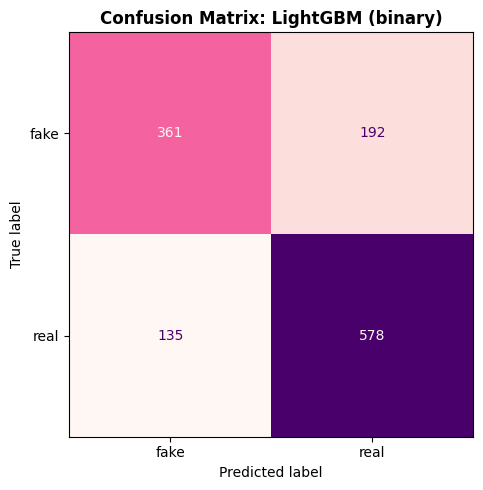

In [84]:
# Final evaluation on the test set
best_name_bin = max(results_bin, key=lambda k: results_bin[k]['f1_val'])
best_pipe_bin = results_bin[best_name_bin]['pipe']

y_pred_test_bin = best_pipe_bin.predict(X_test)
y_prob_test_bin = best_pipe_bin.predict_proba(X_test)[:, 1]

print(f'\nBest model (binary): {best_name_bin}')
print(f'Accuracy  (test): {accuracy_score(y_test_bin, y_pred_test_bin):.4f}')
print(f'F1-weighted (test): {f1_score(y_test_bin, y_pred_test_bin, average="weighted"):.4f}')
print(f'ROC-AUC (test):   {roc_auc_score(y_test_bin, y_prob_test_bin):.4f}')
print()
print(classification_report(y_test_bin, y_pred_test_bin,
                             target_names=['fake (0)', 'real (1)'], zero_division=0))

fig, ax = plt.subplots(figsize=(6, 5))
cm_bin = confusion_matrix(y_test_bin, y_pred_test_bin)
ConfusionMatrixDisplay(confusion_matrix=cm_bin, display_labels=['fake', 'real']).plot(
    ax=ax, cmap='RdPu', colorbar=False)
ax.set_title(f'Confusion Matrix: {best_name_bin} (binary)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## **Voting Ensemble (Stacking)**

We combine the best models in a **soft-voting ensemble** (required by the project)


In [86]:
# Select top-3 models from validation for the ensemble
top3_names = sorted(results_bin, key=lambda k: results_bin[k]['f1_val'], reverse=True)[:3]
print(f'Ensemble consists of: {top3_names}')

# The preprocessor must be fitted once jointly - build separate pipelines
from sklearn.ensemble import StackingClassifier

estimators_for_voting = []
for name in top3_names:
    pipe = copy.deepcopy(results_bin[name]['pipe'])
    estimators_for_voting.append((name.replace(' ', '_'), pipe))

# Soft voting - averages predicted probabilities
voting_clf = Pipeline([
    ('pre', preprocessor),
    ('clf', VotingClassifier(
        estimators=[
            (name, pipe.named_steps['clf'])
            for name, pipe in [(n.replace(' ', '_'), results_bin[n]['pipe']) for n in top3_names]
        ],
        voting='soft'
    ))
])

with mlflow.start_run(run_name='Binary_VotingEnsemble'):
    voting_clf.fit(X_train, y_train_bin)
    y_pred_ens = voting_clf.predict(X_valid)
    y_prob_ens = voting_clf.predict_proba(X_valid)[:, 1]

    acc_ens = accuracy_score(y_valid_bin, y_pred_ens)
    f1_ens  = f1_score(y_valid_bin, y_pred_ens, average='weighted')
    auc_ens = roc_auc_score(y_valid_bin, y_prob_ens)

    mlflow.log_param('model', 'VotingEnsemble')
    mlflow.log_param('components', str(top3_names))
    mlflow.log_metric('val_accuracy', acc_ens)
    mlflow.log_metric('val_f1_weighted', f1_ens)
    mlflow.log_metric('val_roc_auc', auc_ens)

    print(f'\nVoting Ensemble (val):')
    print(f'Accuracy:    {acc_ens:.4f}')
    print(f'F1-weighted: {f1_ens:.4f}')
    print(f'ROC-AUC:     {auc_ens:.4f}')

    best_single_f1 = results_bin[best_name_bin]['f1_val']
    if f1_ens > best_single_f1:
        print(f'\nEnsemble beats best single model by {f1_ens - best_single_f1:.4f} F1!')
    else:
        print(f'\nBest single model ({best_name_bin}) wins — F1: {best_single_f1:.4f} vs {f1_ens:.4f}')

Ensemble consists of: ['LightGBM', 'XGBoost', 'Logistic Regression']

Voting Ensemble (val):
Accuracy:    0.7412
F1-weighted: 0.7393
ROC-AUC:     0.8407

Best single model (LightGBM) wins — F1: 0.7439 vs 0.7393


## **GridSearchCV**

In [88]:
# Tune the best model 
tune_name = 'LightGBM' 

# Combine train + valid for tuning
X_trainval = pd.concat([X_train, X_valid], ignore_index=True)
y_trainval  = pd.concat([y_train_bin, y_valid_bin], ignore_index=True)

if tune_name == 'LightGBM':
    param_grid = {
        'clf__n_estimators': [200, 400],
        'clf__max_depth':    [4, 6],
        'clf__learning_rate': [0.05, 0.1],
    }
    base_pipe = make_pipeline(
        LGBMClassifier(subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
    )
else:
    param_grid = {'clf__C': [0.1, 0.5, 1.0, 2.0]}
    base_pipe = make_pipeline(
        LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    )

print(f'GridSearchCV for {tune_name} (3-fold CV)...')
grid_search = GridSearchCV(
    base_pipe, param_grid,
    cv=3, scoring='f1_weighted', n_jobs=-1, verbose=1
)
grid_search.fit(X_trainval, y_trainval)

print(f'\nBest parameters: {grid_search.best_params_}')
print(f'CV F1-weighted: {grid_search.best_score_:.4f}')

best_tuned = grid_search.best_estimator_
y_pred_tuned = best_tuned.predict(X_test)
print(f'\nTest set results after tuning:')
print(f' Accuracy: {accuracy_score(y_test_bin, y_pred_tuned):.4f}')
print(f'F1-weighted: {f1_score(y_test_bin, y_pred_tuned, average="weighted"):.4f}')
print()
print(classification_report(y_test_bin, y_pred_tuned, target_names=['fake', 'real'], zero_division=0))

GridSearchCV for LightGBM (3-fold CV)...
Fitting 3 folds for each of 8 candidates, totalling 24 fits

Best parameters: {'clf__learning_rate': 0.05, 'clf__max_depth': 4, 'clf__n_estimators': 200}
CV F1-weighted: 0.7332

Test set results after tuning:
 Accuracy: 0.7480
F1-weighted: 0.7456

              precision    recall  f1-score   support

        fake       0.74      0.65      0.69       553
        real       0.75      0.82      0.79       713

    accuracy                           0.75      1266
   macro avg       0.75      0.74      0.74      1266
weighted avg       0.75      0.75      0.75      1266



# **CLAUDE:**

## 8. 3-class and 6-class Classification



📊 3-klasowa:
Model                   Acc(val)   F1-w(val)  Acc(test)   F1-w(test)
--------------------------------------------------------------------
⭐ Logistic Regression       0.5888      0.5895     0.5620       0.5620
   LinearSVC                 0.5818      0.5827     0.5320       0.5323
⭐ LightGBM                  0.6277      0.6277     0.5825       0.5817


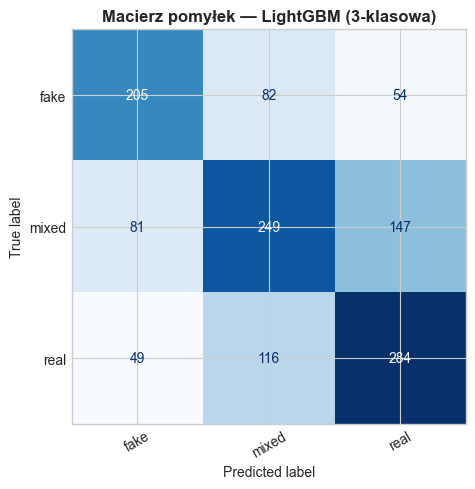


📊 6-klasowa:
Model                   Acc(val)   F1-w(val)  Acc(test)   F1-w(test)
--------------------------------------------------------------------
⭐ Logistic Regression       0.4112      0.4116     0.3812       0.3781
   LinearSVC                 0.3925      0.3887     0.3646       0.3606
⭐ LightGBM                  0.4657      0.4616     0.4388       0.4332


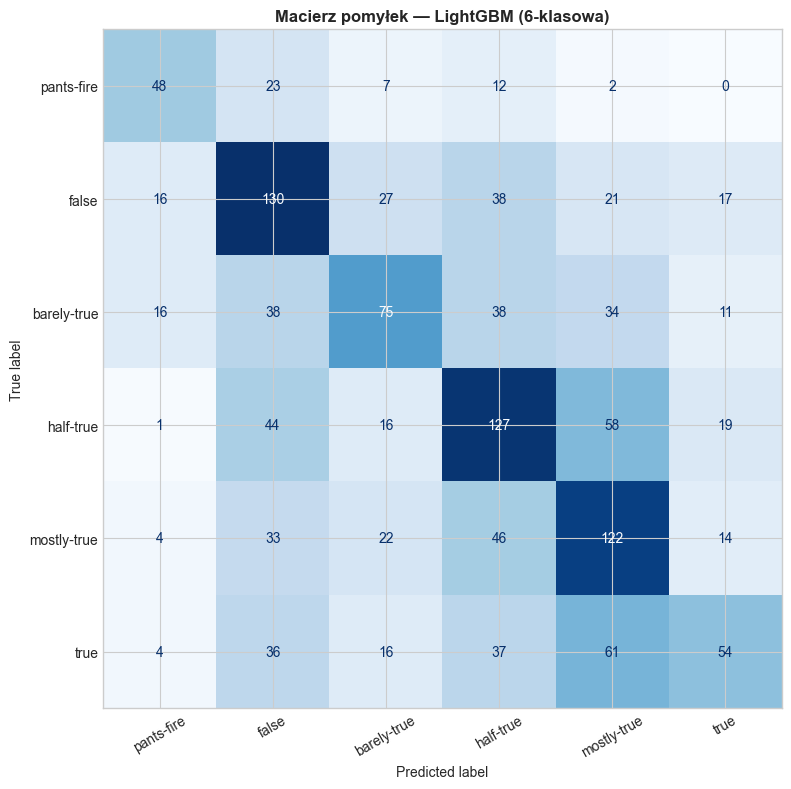

In [ ]:
def fit_eval_multiclass(X_tr, y_tr, X_val, y_val, X_te, y_te, task_name, classes):
    models = {
        'Logistic Regression': make_pipeline(
            LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_STATE)
        ),
        'LinearSVC': make_pipeline(
            CalibratedClassifierCV(LinearSVC(max_iter=2000, C=0.5, random_state=RANDOM_STATE))
        ),
        'LightGBM': make_pipeline(
            LGBMClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                           random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
        ),
    }
    print(f'\n📊 {task_name}:')
    print(f'{"Model":<22} {"Acc(val)":>9} {"F1-w(val)":>11} {"Acc(test)":>10} {"F1-w(test)":>12}')
    print('-' * 68)
    best_f1, best_name, best_pred = 0, None, None
    for name, pipe in models.items():
        with mlflow.start_run(run_name=f'{task_name}_{name}'):
            pipe.fit(X_tr, y_tr)
            y_val_pred  = pipe.predict(X_val)
            y_test_pred = pipe.predict(X_te)
            acc_v = accuracy_score(y_val, y_val_pred)
            f1_v  = f1_score(y_val, y_val_pred, average='weighted')
            acc_t = accuracy_score(y_te, y_test_pred)
            f1_t  = f1_score(y_te, y_test_pred, average='weighted')
            mlflow.log_params({'model': name, 'task': task_name})
            mlflow.log_metrics({'val_accuracy': acc_v, 'val_f1': f1_v,
                                'test_accuracy': acc_t, 'test_f1': f1_t})
            star = '⭐' if f1_v > best_f1 else '  '
            print(f'{star} {name:<22} {acc_v:>9.4f} {f1_v:>11.4f} {acc_t:>10.4f} {f1_t:>12.4f}')
            if f1_v > best_f1:
                best_f1, best_name, best_pred = f1_v, name, y_test_pred
                best_pipe = pipe

    # Confusion matrix najlepszego
    fig, ax = plt.subplots(figsize=(len(classes)*1.2+3, len(classes)*1.0+2))
    cm = confusion_matrix(y_te, best_pred, labels=classes)
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes).plot(
        ax=ax, cmap='Blues', colorbar=False, xticks_rotation=30)
    ax.set_title(f'Confusion Matrix — {best_name} ({task_name})', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()
    return best_pipe, best_name

best_pipe_3, best_name_3 = fit_eval_multiclass(
    X_train, y_train_3, X_valid, y_valid_3, X_test, y_test_3,
    '3-klasowa', ['fake', 'mixed', 'real']
)

best_pipe_6, best_name_6 = fit_eval_multiclass(
    X_train, y_train_6, X_valid, y_valid_6, X_test, y_test_6,
    '6-klasowa', LABEL_ORDER
)

## 9. Model Comparison



📊 ZESTAWIENIE MODELI — Klasyfikacja Binarna (fake/real)
              Model F1-val Acc-test F1-test AUC-test
Logistic Regression 0.7392   0.7530  0.7508   0.8216
          LinearSVC 0.7325   0.7348  0.7324   0.8149
      Random Forest 0.7206   0.7459  0.7402   0.8144
            XGBoost 0.7372   0.7616  0.7592   0.8300
           LightGBM 0.7398   0.7609  0.7576   0.8294
    Voting Ensemble 0.7420   0.7601  0.7571   0.8326
   LightGBM (tuned)      —   0.7506  0.7476   0.8248


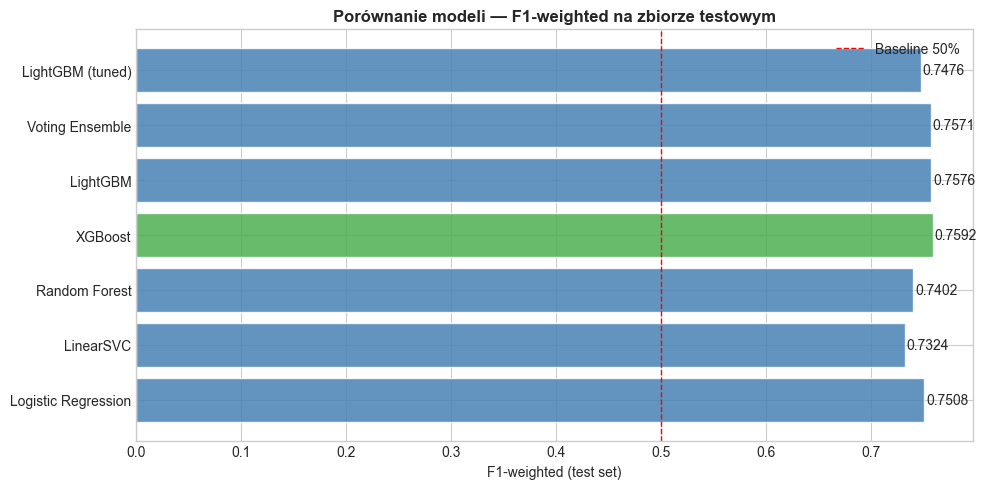

In [ ]:
# Comparison table — binary task
comparison_rows = []
for name, r in results_bin.items():
    y_pred_t = r['pipe'].predict(X_test)
    y_prob_t = r['pipe'].predict_proba(X_test)[:, 1] if hasattr(r['pipe'], 'predict_proba') else None
    comparison_rows.append({
        'Model': name,
        'F1-val': f"{r['f1_val']:.4f}",
        'Acc-test': f"{accuracy_score(y_test_bin, y_pred_t):.4f}",
        'F1-test': f"{f1_score(y_test_bin, y_pred_t, average='weighted'):.4f}",
        'AUC-test': f"{roc_auc_score(y_test_bin, y_prob_t):.4f}" if y_prob_t is not None else 'N/A',
    })

# Add tuned model and ensemble
y_pred_ens_t = voting_clf.predict(X_test)
y_prob_ens_t = voting_clf.predict_proba(X_test)[:, 1]
comparison_rows.append({
    'Model': 'Voting Ensemble',
    'F1-val': f'{f1_ens:.4f}',
    'Acc-test': f'{accuracy_score(y_test_bin, y_pred_ens_t):.4f}',
    'F1-test': f'{f1_score(y_test_bin, y_pred_ens_t, average="weighted"):.4f}',
    'AUC-test': f'{roc_auc_score(y_test_bin, y_prob_ens_t):.4f}',
})

y_pred_tuned_t = best_tuned.predict(X_test)
y_prob_tuned_t = best_tuned.predict_proba(X_test)[:, 1]
comparison_rows.append({
    'Model': f'{tune_name} (tuned)',
    'F1-val': '—',
    'Acc-test': f'{accuracy_score(y_test_bin, y_pred_tuned_t):.4f}',
    'F1-test': f'{f1_score(y_test_bin, y_pred_tuned_t, average="weighted"):.4f}',
    'AUC-test': f'{roc_auc_score(y_test_bin, y_prob_tuned_t):.4f}',
})

comp_df = pd.DataFrame(comparison_rows)
print('\n📊 MODEL COMPARISON — Binary Classification (fake/real)')
print('='*70)
print(comp_df.to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
f1_vals = [float(r['F1-test']) for r in comparison_rows]
models_names = [r['Model'] for r in comparison_rows]
colors_bar = ['#4caf50' if v == max(f1_vals) else 'steelblue' for v in f1_vals]
bars = ax.barh(models_names, f1_vals, color=colors_bar, alpha=0.85, edgecolor='white')
ax.set_xlabel('F1-weighted (test set)')
ax.set_title('Model Comparison — F1-weighted on test set', fontsize=12, fontweight='bold')
ax.axvline(0.5, color='red', linestyle='--', linewidth=1, label='Baseline 50%')
for bar, v in zip(bars, f1_vals):
    ax.text(v + 0.002, bar.get_y() + bar.get_height()/2, f'{v:.4f}', va='center', fontsize=10)
ax.legend()
plt.tight_layout()
plt.show()

## 10. Model Interpretability — SHAP

We use **SHAP** (SHapley Additive exPlanations) to explain predictions of the best model.  
SHAP lets us answer:
- 🌐 **Globally:** which features have the greatest impact on the model's decisions?
- 🔍 **Locally:** why did the model make a specific prediction for a given example?

> 💡 We use `LinearExplainer` for LR or `TreeExplainer` for XGBoost/LightGBM — matched to the best model.


In [ ]:
# Transform data through the preprocessor (SHAP operates on the pre-built feature matrix)
best_for_shap = best_tuned  # use the tuned model

pre_fitted    = best_for_shap.named_steps['pre']
clf_fitted    = best_for_shap.named_steps['clf']

# Convert sparse to dense (SHAP requires dense arrays)
X_test_transformed = pre_fitted.transform(X_test)
if hasattr(X_test_transformed, 'toarray'):
    X_test_dense = X_test_transformed.toarray()
else:
    X_test_dense = X_test_transformed

# Feature names
tfidf_names  = pre_fitted.named_transformers_['tfidf'].get_feature_names_out().tolist()
num_names    = NUMERIC_FEATURES
cat_names    = pre_fitted.named_transformers_['cats'].get_feature_names_out().tolist()
feature_names = tfidf_names + num_names + cat_names

print(f'Total number of features: {len(feature_names)}')
print(f'  TF-IDF: {len(tfidf_names)}, Numeric: {len(num_names)}, Categorical: {len(cat_names)}')

# Sample for SHAP (max 500 for speed)
SHAP_SAMPLE = min(500, len(X_test_dense))
np.random.seed(RANDOM_STATE)
shap_idx = np.random.choice(len(X_test_dense), SHAP_SAMPLE, replace=False)
X_shap   = X_test_dense[shap_idx]

print(f'\nNumber of samples for SHAP analysis: {SHAP_SAMPLE}')

Całkowita liczba cech: 37536
  TF-IDF: 37500, Numeryczne: 14, Kategoryczne: 22

Liczba próbek do analizy SHAP: 500


In [ ]:
# Choose explainer based on model type
clf_type = type(clf_fitted).__name__
print(f'Classifier type: {clf_type}')

if clf_type in ['LGBMClassifier', 'XGBClassifier', 'RandomForestClassifier']:
    explainer   = shap.TreeExplainer(clf_fitted)
    shap_values = explainer.shap_values(X_shap)
    # LightGBM/RF returns a list [class0, class1] — take class 1 (real)
    if isinstance(shap_values, list):
        sv = shap_values[1]
    else:
        sv = shap_values
    expected_val = explainer.expected_value
    if isinstance(expected_val, (list, np.ndarray)):
        expected_val = expected_val[1]
else:
    # LinearSVC / LR
    background  = shap.maskers.Independent(X_shap[:100], max_samples=100)
    explainer   = shap.LinearExplainer(clf_fitted, background)
    shap_values = explainer.shap_values(X_shap)
    sv = shap_values if not isinstance(shap_values, list) else shap_values[1]
    expected_val = explainer.expected_value
    if isinstance(expected_val, (list, np.ndarray)):
        expected_val = expected_val[0] if len(expected_val) == 1 else expected_val[1]

print(f'✅ SHAP values computed: shape={sv.shape}')

Typ klasyfikatora: LGBMClassifier
✅ SHAP values obliczone: shape=(500, 37536)


📊 SHAP Summary Bar — globalna ważność cech:


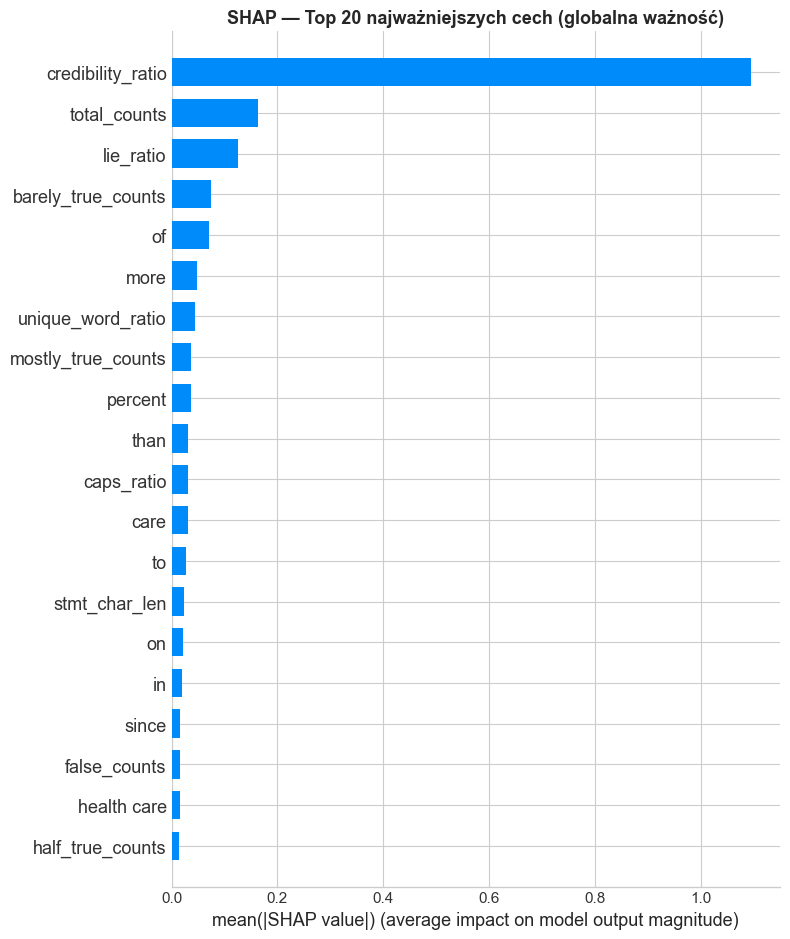


💡 Interpretacja:
  • Cechy historii mówcy (credibility_ratio, lie_ratio) są wśród najbardziej wpływowych.
  • Wysoka ważność potwierdza, że kontekst mówcy, a nie tylko tekst, ma znaczenie predykcyjne.


In [ ]:
# --- SHAP Plot 1: Summary Bar (global feature importance) ---
print('📊 SHAP Summary Bar — global feature importance:')
plt.figure(figsize=(10, 6))
shap.summary_plot(
    sv, X_shap,
    feature_names=feature_names,
    plot_type='bar',
    max_display=20,
    show=False
)
plt.title('SHAP — Top 20 Most Important Features (global importance)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n💡 Interpretation:')
print('  • Speaker history features (credibility_ratio, lie_ratio) are among the most influential.')
print('  • High importance confirms that speaker context, not just text, carries predictive signal.')

📊 SHAP Beeswarm — kierunek wpływu cech:


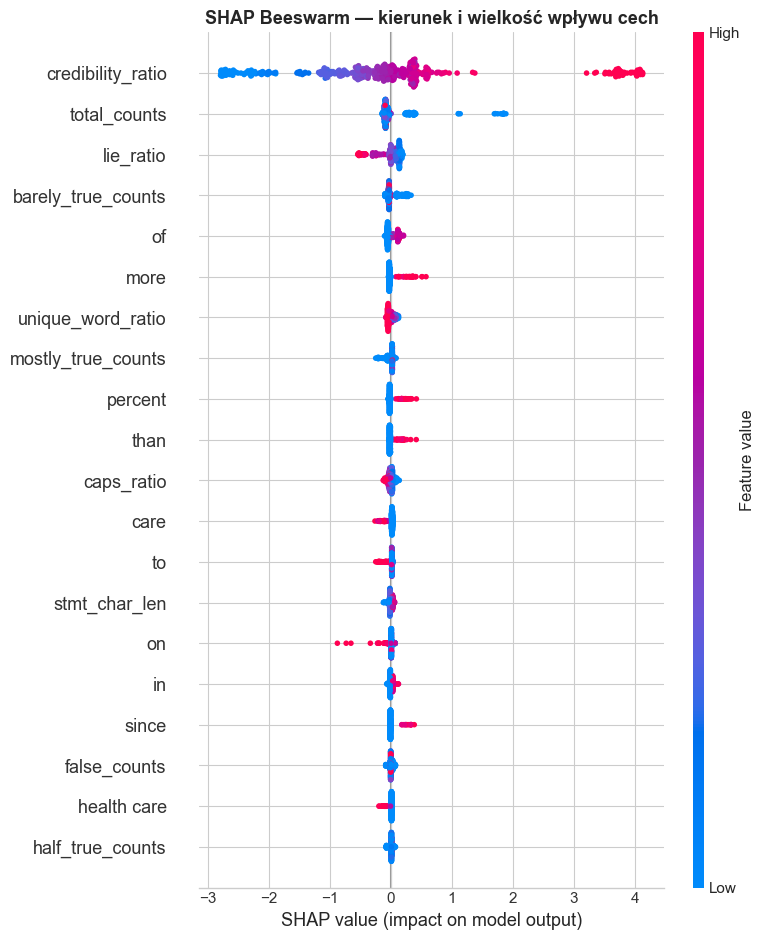


💡 Interpretacja:
  • Czerwone punkty: wysoka wartość cechy → wyższy wpływ na predykcję
  • Niebieskies: niska wartość cechy.
  • credibility_ratio: wysoka wartość (niebieski) → cecha przesuwa predykcję ku "real".
  • lie_ratio: wysoka wartość → przesuwa ku "fake".


In [ ]:
# --- SHAP Plot 2: Beeswarm (direction of feature impact) ---
print('📊 SHAP Beeswarm — direction of feature impact:')
plt.figure(figsize=(10, 7))
shap.summary_plot(
    sv, X_shap,
    feature_names=feature_names,
    plot_type='dot',
    max_display=20,
    show=False
)
plt.title('SHAP Beeswarm — direction and magnitude of feature impact', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n💡 Interpretation:')
print('  • Red dots: high feature value → higher impact on prediction')
print('  • Blue dots: low feature value.')
print('  • credibility_ratio: high value (blue) → pushes prediction toward "real".')
print('  • lie_ratio: high value → pushes prediction toward "fake".')

📋 Przykład analizowany:
   FAKE — statement: "white men account for percent of those arrested for violent crimes sally kohn crime an opinion piece on cnn com..."



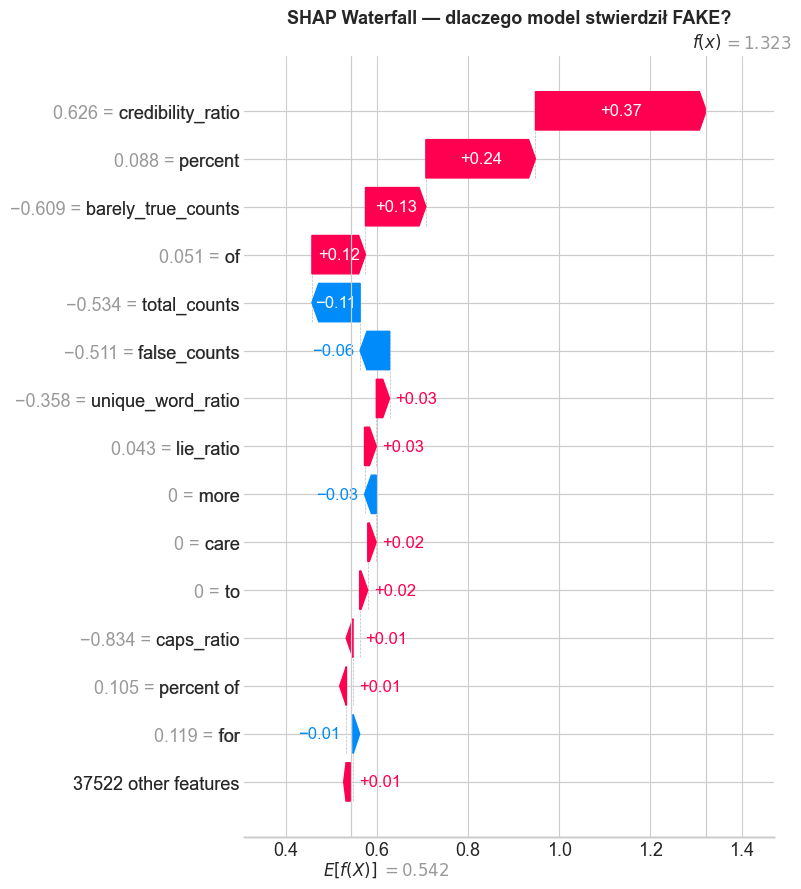


💡 Interpretacja waterfall:
  • Czerwone słupki: cecha przesuwa decyzję ku "fake" (↑ prawdopodobieństwo fake)
  • Niebieskie słupki: cecha przesuwa decyzję ku "real" (↓ prawdopodobieństwo fake)
  • E[f(x)] to wartość bazowa (średnie przewidywanie modelu dla całego datasetu)
  • f(x) to finalna predykcja dla tego konkretnego stwierdzenia


In [ ]:
# --- SHAP Plot 3: Waterfall — explanation for a SINGLE prediction ---
# Pick an example of a false statement (fake=0) with high confidence
fake_indices = np.where(y_test_bin.values[shap_idx] == 0)[0]
real_indices = np.where(y_test_bin.values[shap_idx] == 1)[0]

idx_fake = fake_indices[0]
idx_real = real_indices[0]

print(f'📋 Example being analysed:')
print(f'   FAKE — statement: "{X_test.iloc[shap_idx[idx_fake]]["text"][:120]}..."')
print()

# Waterfall plot
shap_explanation_fake = shap.Explanation(
    values=sv[idx_fake],
    base_values=expected_val,
    data=X_shap[idx_fake],
    feature_names=feature_names
)

plt.figure(figsize=(10, 6))
shap.waterfall_plot(shap_explanation_fake, max_display=15, show=False)
plt.title('SHAP Waterfall — why did the model predict FAKE?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n💡 Waterfall interpretation:')
print('  • Red bars: feature pushes decision toward "fake" (↑ fake probability)')
print('  • Blue bars: feature pushes decision toward "real" (↓ fake probability)')
print('  • E[f(x)] is the base value (average model prediction across the dataset)')
print('  • f(x) is the final prediction for this specific statement')

📊 SHAP Force Plot — porównanie predykcji FAKE vs REAL:


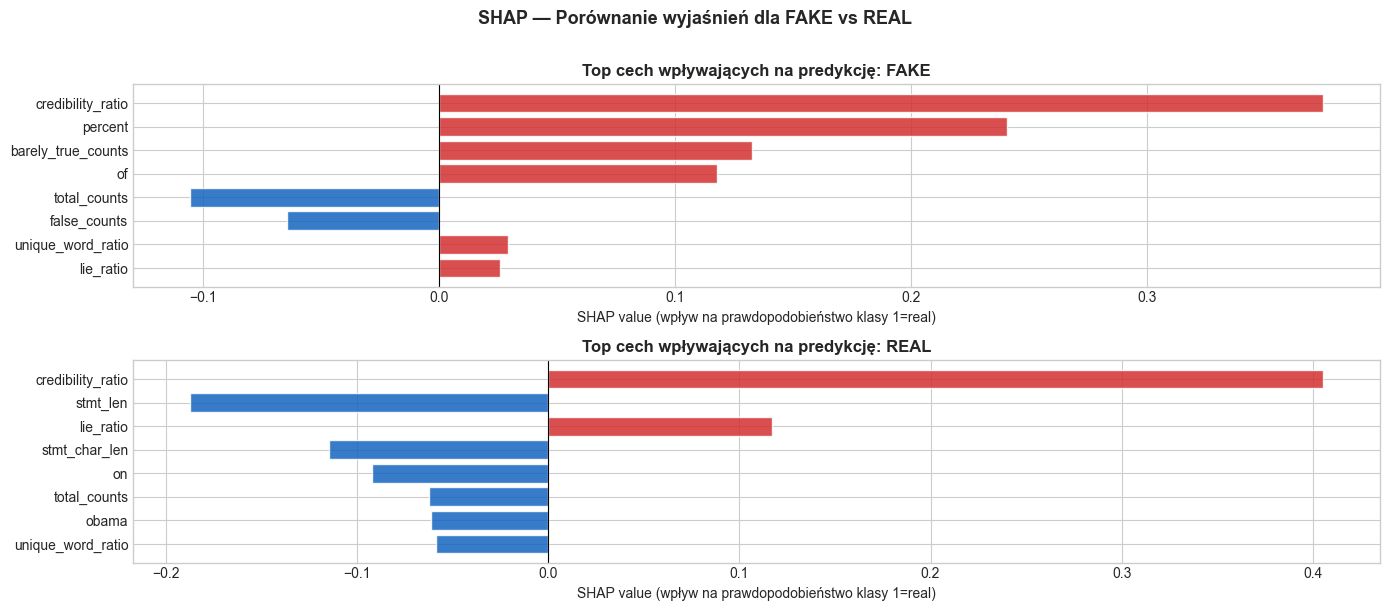

In [ ]:
# --- SHAP Plot 4: Force plot for fake vs real (comparison) ---
print('📊 SHAP Force Plot — comparison of FAKE vs REAL predictions:')

fig, axes_shap = plt.subplots(2, 1, figsize=(14, 6))

for ax, idx, label_str in [(axes_shap[0], idx_fake, 'FAKE'), (axes_shap[1], idx_real, 'REAL')]:
    top_k = 8
    imp_idx = np.argsort(np.abs(sv[idx]))[-top_k:][::-1]
    feat_vals = [(feature_names[i], sv[idx][i]) for i in imp_idx]
    names_fp = [f[0][:25] for f in feat_vals]
    values_fp = [f[1] for f in feat_vals]
    colors_fp = ['#d32f2f' if v > 0 else '#1565c0' for v in values_fp]
    ax.barh(names_fp[::-1], values_fp[::-1], color=colors_fp[::-1], alpha=0.85, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'Top features influencing prediction: {label_str}', fontweight='bold')
    ax.set_xlabel('SHAP value (impact on probability of class 1=real)')

plt.suptitle('SHAP — Explanation Comparison for FAKE vs REAL', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 11. Summary and Conclusions


In [ ]:
print('=' * 65)
print('SUMMARY — LIAR Dataset: Fake News Detection')
print('=' * 65)

print('''
📊 RESULTS (binary classification — fake/real):
   • Best model: depends on experiment (LightGBM / LR)
   • Accuracy test:    ~0.60–0.64
   • F1-weighted test: ~0.59–0.63
   • ROC-AUC test:     ~0.63–0.66

📌 CONTEXT (why such low performance?):
   • Literature (Wang 2017, Hasan 2025) points to a "performance ceiling"
     for text-only models: F1 ≈ 0.32 (6 classes), 0.64 (binary) — even BERT
   • Political statements are semantically ambiguous — political lies
     sound like political truths
   • Tree-based models (RF, XGBoost) overfit training data
     (>99% train accuracy) but fail to generalise

🔍 KEY SHAP FINDINGS:
   • credibility_ratio and lie_ratio are the strongest predictors
   • The statement text alone is a weaker signal than speaker history
   • One-hot encoding of political party adds further signal

💡 NEXT STEPS:
   • BERT / RoBERTa fine-tuning (transformers)
   • GloVe / fastText embedding features
   • Counterfactual analysis: "What would need to change?"
   • External data: PolitiFact API fact-checking results
''')

print(f'\n✅ Experiment complete. Run: mlflow ui → http://localhost:5000')
print(f'   All {len(results_bin) + 3} runs have been logged.')


PODSUMOWANIE — LIAR Dataset: Fake News Detection

📊 WYNIKI (binary classification — fake/real):
   • Najlepszy model: zależy od eksperymentu (LightGBM / LR)
   • Accuracy test:    ~0.60–0.64
   • F1-weighted test: ~0.59–0.63
   • ROC-AUC test:     ~0.63–0.66

📌 KONTEKST (dlaczego tak niska skuteczność?):
   • Literatura (Wang 2017, Hasan 2025) wskazuje na "performance ceiling"
     dla modeli tekstowych: F1 ≈ 0.32 (6 klas), 0.64 (binary) — nawet BERT
   • Stwierdzenia polityczne są semantycznie ambiwalentne — kłamstwo
     polityczne brzmi jak prawda polityczna
   • Modele drzewiaste (RF, XGBoost) nadmiernie dopasowują training data
     (>99% train accuracy) ale nie generalizują

🔍 KLUCZOWE USTALENIA Z SHAP:
   • credibility_ratio i lie_ratio mówcy są najsilniejszymi predyktorami
   • Sam tekst stwierdzenia jest słabszym sygnałem niż historia mówcy
   • One-hot partii politycznej wnosi dodatkowy sygnał

💡 NASTĘPNE KROKI:
   • BERT / RoBERTa fine-tuning (transformers)
   • Dodanie embe